# Project 1 — Step 4: Disease Prediction Model

Goal: predict **Diabetic_Status** (Diabetic vs. Not Diabetic) from patient
variablesl
type (multi-class-capable, since Diabetic_Status also has a "Prediabetic"
category). 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

FILE_PATH = "hospital_patient_dataset.xlsx"
df = pd.read_excel(FILE_PATH, sheet_name="Patient_Dataset")
df["Diabetic_Status"].value_counts()

Diabetic_Status
Prediabetic     116
Not Diabetic    100
Diabetic         34
Name: count, dtype: int64

## 1. Feature engineering

Note: `Blood_Glucose_mgdL` is what *defines* Diabetic_Status in this dataset
(that's how it was generated), so we exclude it here — otherwise the model
would just be memorizing the rule instead of learning from independent
clinical signals. This mirrors a real project: you drop features that leak
the answer.

In [2]:
df["N_Comorbidities"] = df["Comorbidities"].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip().lower() == "none" else len(str(x).split(","))
)
df["Is_Emergency"] = (df["Admission_Type"] == "Emergency").astype(int)
df["Family_History_Diabetes_Flag"] = (df["Family_History_Diabetes"] == "Yes").astype(int)

FEATURE_COLS = [
    "Age", "BMI", "Systolic_BP", "Diastolic_BP", "Cholesterol_mgdL",
    "N_Comorbidities", "Is_Emergency", "Family_History_Diabetes_Flag",
    "Previous_Admissions", "Previous_Visits_1Yr", "Medications_Count"
]
TARGET_COL = "Diabetic_Status"

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL]  # 3 classes: Diabetic / Prediabetic / Not Diabetic

y.value_counts()

Diabetic_Status
Prediabetic     116
Not Diabetic    100
Diabetic         34
Name: count, dtype: int64

## 2. Train/test split and scaling

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (200, 11)  Test size: (50, 11)


## 3. Train the model (multinomial Logistic Regression)

In [8]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.48

              precision    recall  f1-score   support

    Diabetic       0.25      0.14      0.18         7
Not Diabetic       0.53      0.40      0.46        20
 Prediabetic       0.48      0.65      0.56        23

    accuracy                           0.48        50
   macro avg       0.42      0.40      0.40        50
weighted avg       0.47      0.48      0.46        50



## 4. Confusion matrix

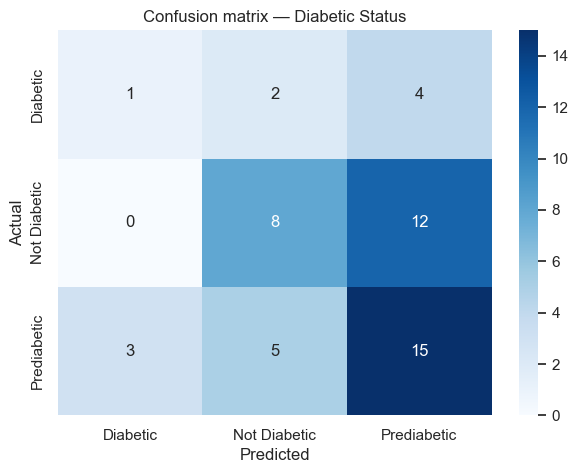

In [5]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Diabetic Status")
plt.show()

## 5. Compare with Random Forest

Random Forest handles multi-class targets and non-linear effects natively —
often a stronger baseline than logistic regression on messy real-world data.

Random Forest accuracy: 0.48

              precision    recall  f1-score   support

    Diabetic       0.25      0.14      0.18         7
Not Diabetic       0.44      0.35      0.39        20
 Prediabetic       0.53      0.70      0.60        23

    accuracy                           0.48        50
   macro avg       0.41      0.40      0.39        50
weighted avg       0.46      0.48      0.46        50



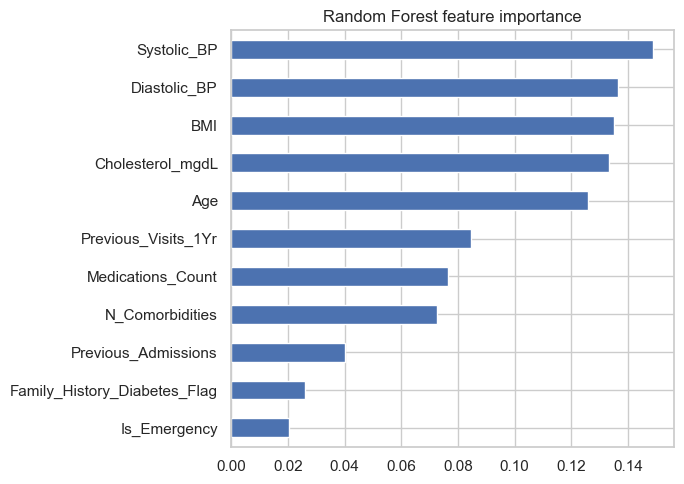

In [6]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print()
print(classification_report(y_test, rf_pred))

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", figsize=(7, 5), title="Random Forest feature importance")
plt.tight_layout()
plt.show()

## 6. Predict for a new patient

In [7]:
def predict_diabetic_status(age, bmi, systolic_bp, diastolic_bp, cholesterol,
                             n_comorbidities, is_emergency, family_history_diabetes,
                             prev_admissions, prev_visits, medications):
    row = pd.DataFrame([[age, bmi, systolic_bp, diastolic_bp, cholesterol,
                          n_comorbidities, is_emergency, family_history_diabetes,
                          prev_admissions, prev_visits, medications]],
                        columns=FEATURE_COLS)
    row_s = scaler.transform(row)
    pred = clf.predict(row_s)[0]
    proba = dict(zip(clf.classes_, clf.predict_proba(row_s)[0].round(3)))
    return pred, proba

# Example: 55-year-old, high BMI, family history of diabetes
predict_diabetic_status(age=55, bmi=31, systolic_bp=138, diastolic_bp=88,
                         cholesterol=210, n_comorbidities=1, is_emergency=0,
                         family_history_diabetes=1, prev_admissions=1,
                         prev_visits=2, medications=2)

('Prediabetic',
 {'Diabetic': np.float64(0.253),
  'Not Diabetic': np.float64(0.226),
  'Prediabetic': np.float64(0.521)})